In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import gc

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from scipy.stats import spearmanr
from nltk.corpus import stopwords
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

eng_stopwords = set(stopwords.words("english"))


2026-01-07 02:41:07.036188: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767753667.050304      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767753667.054608      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 02:41:07.072913: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/kaggle/input/test.csv.zip
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/description.md
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv
/kaggle/input/google-quest-challenge/test.csv.zip
/kaggle/input/google-quest-challenge/test.csv
/kaggle/input/google-quest-challenge/sample_submission.csv.zip
/kaggle/input/google-quest-challenge/train.csv.zip
/kaggle/input/google-quest-challenge/description.md
/kaggle/input/google-quest-challenge/sample_submission.csv
/kaggle/input/google-quest-challenge/train.csv


In [2]:
%%time
train_df = pd.read_csv('/kaggle/input/google-quest-challenge/train.csv')
sample_sub_df = pd.read_csv('/kaggle/input/google-quest-challenge/sample_submission.csv')
test_df = pd.read_csv('/kaggle/input/google-quest-challenge/test.csv')


CPU times: user 102 ms, sys: 11.6 ms, total: 114 ms
Wall time: 115 ms


In [3]:
pd.set_option('display.max_columns', None)
train_df.head()


,qa_id,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host,question_asker_intent_understanding,question_body_critical,question_conversational,question_expect_short_answer,question_fact_seeking,question_has_commonly_accepted_answer,question_interestingness_others,question_interestingness_self,question_multi_intent,question_not_really_a_question,question_opinion_seeking,question_type_choice,question_type_compare,question_type_consequence,question_type_definition,question_type_entity,question_type_instructions,question_type_procedure,question_type_reason_explanation,question_type_spelling,question_well_written,answer_helpful,answer_level_of_information,answer_plausible,answer_relevance,answer_satisfaction,answer_type_instructions,answer_type_procedure,answer_type_reason_explanation,answer_well_written
0,9622,Which parts of fresh Fenugreek am I supposed t...,The fresh Fenugreek which I bought contains:\n...,Aquarius_Girl,https://cooking.stackexchange.com/users/6168,I would just pull off all the little stems wit...,spiceyokooko,https://cooking.stackexchange.com/users/14539,http://cooking.stackexchange.com/questions/292...,LIFE_ARTS,cooking.stackexchange.com,1.000000,1.000000,0.0,1.000000,0.666667,1.0,0.555556,0.333333,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.333333,0.333333,0.333333,0.000000,0.0,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,0.666667,0.333333,0.000000,1.000000
1,3515,Is decoherence even possible in anti de Sitter...,Is decoherence even possible in anti de Sitter...,theorist,https://physics.stackexchange.com/users/6788,"Your question is not about AdS at all, it is a...",Ron Maimon,https://physics.stackexchange.com/users/4864,http://physics.stackexchange.com/questions/185...,SCIENCE,physics.stackexchange.com,1.000000,1.000000,0.0,0.000000,1.000000,1.0,1.000000,1.000000,1.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
2,2012,How to show the integers have same cardinality...,How would I show the following have a bijectio...,Fernando Martinez,https://math.stackexchange.com/users/37244,"I like the one that snake around, $0, -1, 1, -...",Adam Hughes,https://math.stackexchange.com/users/58831,http://math.stackexchange.com/questions/873927...,SCIENCE,math.stackexchange.com,0.888889,0.888889,0.0,0.666667,1.000000,1.0,0.444444,0.333333,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.000000,1.000000,0.666667,0.333333,0.0,0.777778,0.888889,0.666667,1.000000,0.888889,0.866667,0.666667,0.666667,0.333333,0.777778
3,5460,how to pass value from visual force page (Inpu...,I have created a Vf page from which i need to ...,jack,https://salesforce.stackexchange.com/users/8706,"When you submit the page, Visualforce will upd...",Keith C,https://salesforce.stackexchange.com/users/887,http://salesforce.stackexchange.com/questions/...,TECHNOLOGY,salesforce.stackexchange.com,1.000000,0.777778,0.0,0.666667,0.333333,1.0,0.444444,0.333333,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.000000,0.0,0.888889,1.000000,0.666667,1.000000,1.000000,0.933333,1.000000,0.000000,0.000000,0.888889
4,2046,How to set precision and format labeled Slider...,"For my calculations, I need increased precisio...",Cendo,https://mathematica.stackexchange.com/users/1290,"Two, now three, ways: I think I'd recommend t...",Michael E2,https://mathematica.stackexchange.com/users/4999,http://mathematica.stackexchange.com/questions...,TECHNOLOGY,mathematica.stackexchange.com,0.888889,0.666667,0.0,1.000000,0.666667,1.0,0.444444,0.333333,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.333333,0.0,1.000000,0.888889,0.833333,0.888889,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000


In [4]:
test_df.head()


,qa_id,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host
0,6516,"""Hirable"" or ""hireable""",What is the correct adjective form of the word...,Greg Bray,https://english.stackexchange.com/users/9063,Apparently the rule for attaching suffixes is ...,Thursagen,https://english.stackexchange.com/users/8183,http://english.stackexchange.com/questions/269...,CULTURE,english.stackexchange.com
1,6168,Setting text of UITextField from caller view,"I have a barcode scanner on one view, and afte...",Freeman Latif,https://stackoverflow.com/users/823152,you just have to synthesize the barcode and in...,Ahsan,https://stackoverflow.com/users/1570507,http://stackoverflow.com/questions/14960306/se...,STACKOVERFLOW,stackoverflow.com
2,8575,What is a word for somebody who lies to themse...,I feel like the fact that people lie to themse...,Petar,https://english.stackexchange.com/users/64497,In psychology this is known as denial and it i...,user69617,https://english.stackexchange.com/users/69617,http://english.stackexchange.com/questions/158...,CULTURE,english.stackexchange.com
3,618,Is using PHP NuSOAP a bad idea?,I read somewhere here on stackoverflow that us...,Indy,https://stackoverflow.com/users/1058892,"If you're working with PHP4, it might be your ...",Anas,https://stackoverflow.com/users/235659,http://stackoverflow.com/questions/10746370/is...,STACKOVERFLOW,stackoverflow.com
4,3471,Log In / Sign Up on Splash screen?,Is it common to include Login / Sign Up action...,Romano,https://ux.stackexchange.com/users/59446,"Avoid a splash screen, they are more for show ...",80gm2,https://ux.stackexchange.com/users/40376,http://ux.stackexchange.com/questions/69984/lo...,TECHNOLOGY,ux.stackexchange.com


In [5]:
sample_sub_df.head()


,qa_id,question_asker_intent_understanding,question_body_critical,question_conversational,question_expect_short_answer,question_fact_seeking,question_has_commonly_accepted_answer,question_interestingness_others,question_interestingness_self,question_multi_intent,question_not_really_a_question,question_opinion_seeking,question_type_choice,question_type_compare,question_type_consequence,question_type_definition,question_type_entity,question_type_instructions,question_type_procedure,question_type_reason_explanation,question_type_spelling,question_well_written,answer_helpful,answer_level_of_information,answer_plausible,answer_relevance,answer_satisfaction,answer_type_instructions,answer_type_procedure,answer_type_reason_explanation,answer_well_written
0,6516,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,6168,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647
2,8575,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295
3,618,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942
4,3471,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590


In [6]:
print (f'Sahpe of training set: {train_df.shape}')
print (f'Sahpe of testing set: {test_df.shape}')


Sahpe of training set: (5471, 41)
Sahpe of testing set: (608, 11)


In [7]:
train_df.columns


Index(['qa_id', 'question_title', 'question_body', 'question_user_name',
       'question_user_page', 'answer', 'answer_user_name', 'answer_user_page',
       'url', 'category', 'host', 'question_asker_intent_understanding',
       'question_body_critical', 'question_conversational',
       'question_expect_short_answer', 'question_fact_seeking',
       'question_has_commonly_accepted_answer',
       'question_interestingness_others', 'question_interestingness_self',
       'question_multi_intent', 'question_not_really_a_question',
       'question_opinion_seeking', 'question_type_choice',
       'question_type_compare', 'question_type_consequence',
       'question_type_definition', 'question_type_entity',
       'question_type_instructions', 'question_type_procedure',
       'question_type_reason_explanation', 'question_type_spelling',
       'question_well_written', 'answer_helpful',
       'answer_level_of_information', 'answer_plausible', 'answer_relevance',
       'answer_satisfa

In [8]:
sns.set(rc={'figure.figsize':(11,8)})
sns.set(style="whitegrid")


In [9]:
total = len(train_df)


In [10]:
ax = sns.barplot(train_df['category'].value_counts().keys(), train_df['category'].value_counts())
ax.set(xlabel='Category', ylabel='# of records', title='Category vs. # of records')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
for p in ax.patches: # loop to all objects and plot group wise % distribution
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 5,
            '{:1.2f}%'.format(height/total*100),
            ha="center", fontsize=15) 

plt.show()


TypeError: barplot() takes from 0 to 1 positional arguments but 2 were given

In [11]:
v = np.vectorize(lambda x: x.split('.')[0])
sns.set(rc={'figure.figsize':(15,8)})
ax = sns.barplot(v(train_df['host'].value_counts().keys().values), train_df['host'].value_counts())
ax.set(xlabel='Host platforms', ylabel='# of records', title='Host platforms vs. # of records')
ax.set_xticklabels(ax.get_xticklabels(), rotation=50, ha="right")
plt.show()


TypeError: barplot() takes from 0 to 1 positional arguments but 2 were given

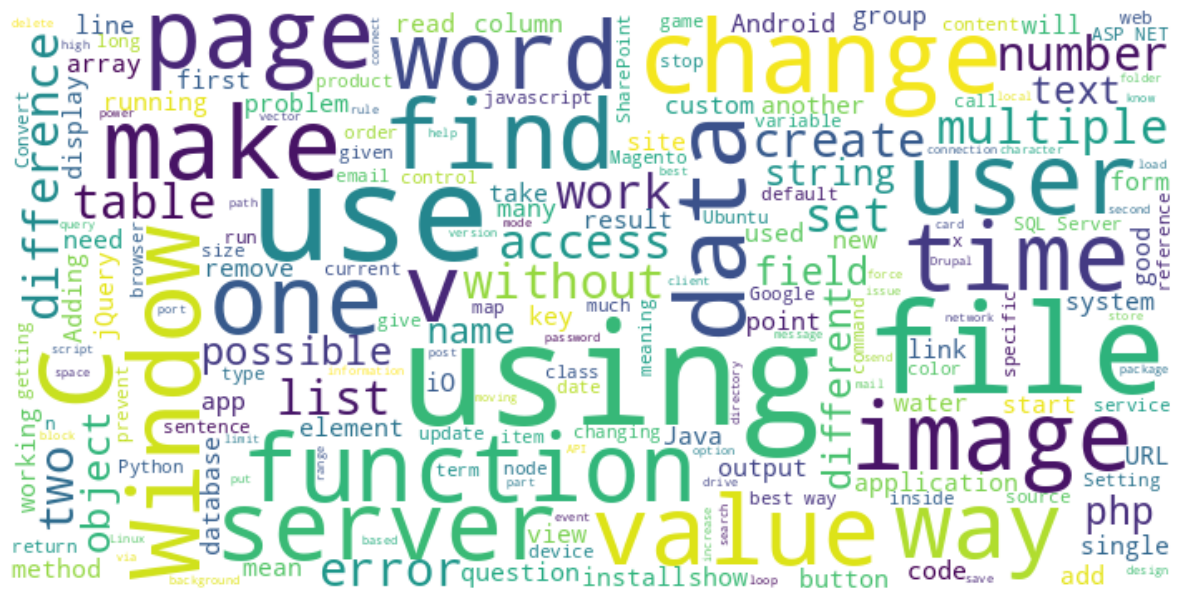

In [12]:
wc = WordCloud(background_color='white', max_font_size = 85, width=700, height=350)
wc.generate(','.join(train_df['question_title'].tolist()))
plt.figure(figsize=(15,10))
plt.axis("off")
plt.imshow(wc, interpolation='bilinear')


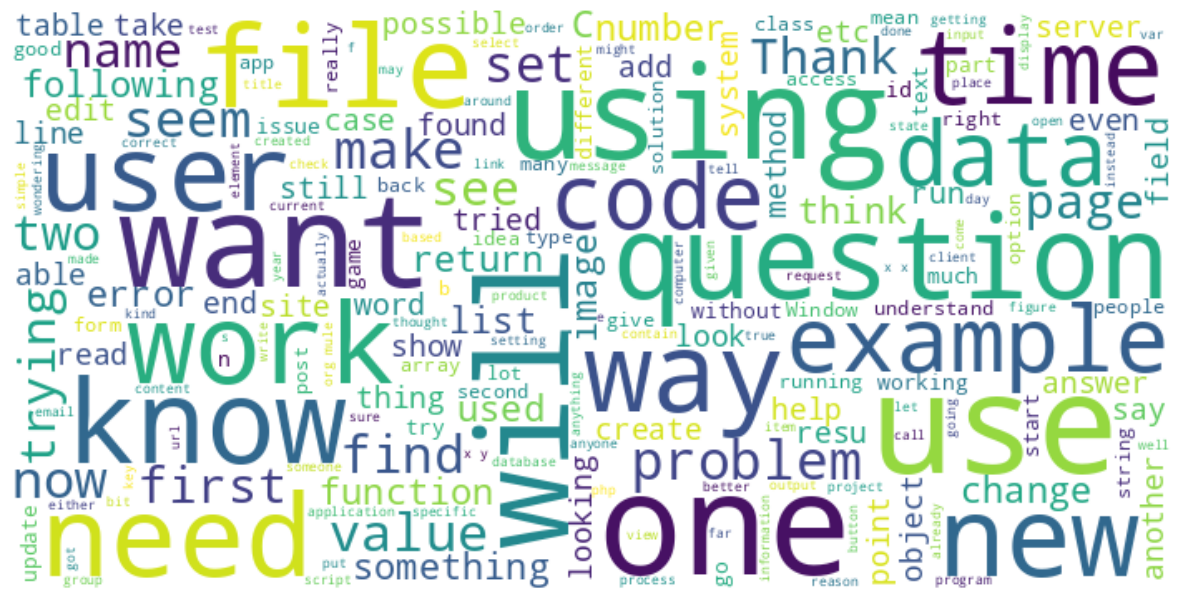

In [13]:
wc.generate(','.join(train_df['question_body'].tolist()).replace('gt', '').replace('lt', ''))
plt.figure(figsize=(15,10))
plt.axis("off")
plt.imshow(wc, interpolation='bilinear')


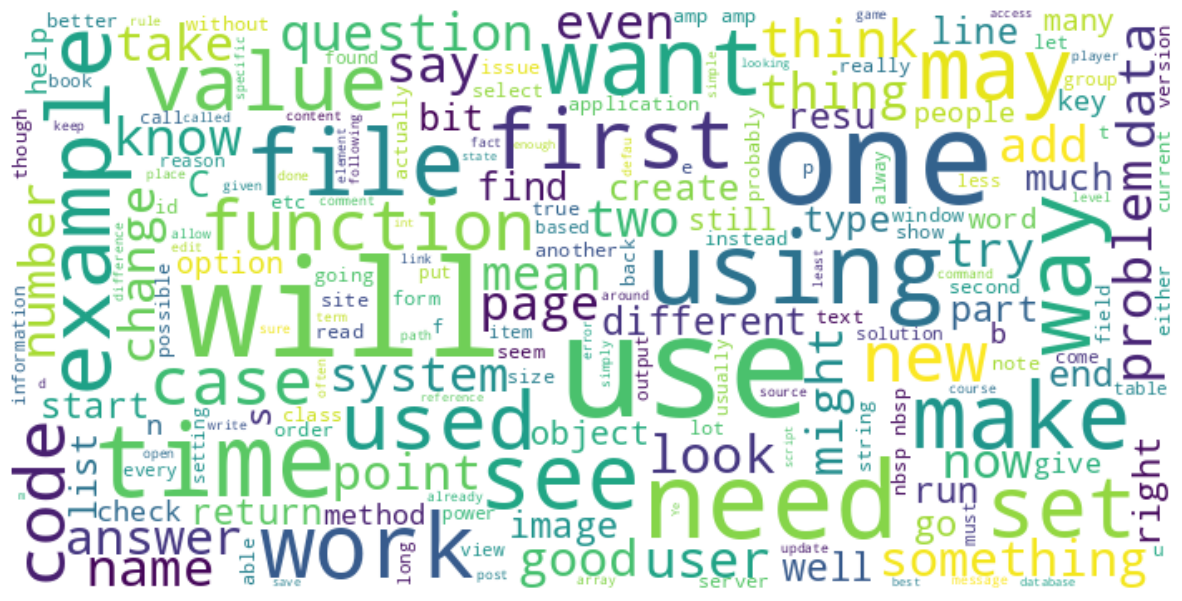

In [14]:
wc.generate(','.join(train_df['answer'].tolist()).replace('gt', '').replace('lt', ''))
plt.figure(figsize=(15,10))
plt.axis("off")
plt.imshow(wc, interpolation='bilinear')


In [15]:
target_cols = sample_sub_df.drop(['qa_id'], axis=1).columns.values
target_cols


array(['question_asker_intent_understanding', 'question_body_critical',
       'question_conversational', 'question_expect_short_answer',
       'question_fact_seeking', 'question_has_commonly_accepted_answer',
       'question_interestingness_others', 'question_interestingness_self',
       'question_multi_intent', 'question_not_really_a_question',
       'question_opinion_seeking', 'question_type_choice',
       'question_type_compare', 'question_type_consequence',
       'question_type_definition', 'question_type_entity',
       'question_type_instructions', 'question_type_procedure',
       'question_type_reason_explanation', 'question_type_spelling',
       'question_well_written', 'answer_helpful',
       'answer_level_of_information', 'answer_plausible',
       'answer_relevance', 'answer_satisfaction',
       'answer_type_instructions', 'answer_type_procedure',
       'answer_type_reason_explanation', 'answer_well_written'],
      dtype=object)

In [16]:
X_train = train_df.drop(np.concatenate([target_cols, np.array(['qa_id'])]), axis=1)
Y_train = train_df[target_cols]


In [17]:
print (f'Shape of X_train: {X_train.shape}')
print (f'Shape of Y_train: {Y_train.shape}')


Shape of X_train: (5471, 10)
Shape of Y_train: (5471, 30)


In [18]:
X_train.head()


,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host
0,Which parts of fresh Fenugreek am I supposed t...,The fresh Fenugreek which I bought contains:\n...,Aquarius_Girl,https://cooking.stackexchange.com/users/6168,I would just pull off all the little stems wit...,spiceyokooko,https://cooking.stackexchange.com/users/14539,http://cooking.stackexchange.com/questions/292...,LIFE_ARTS,cooking.stackexchange.com
1,Is decoherence even possible in anti de Sitter...,Is decoherence even possible in anti de Sitter...,theorist,https://physics.stackexchange.com/users/6788,"Your question is not about AdS at all, it is a...",Ron Maimon,https://physics.stackexchange.com/users/4864,http://physics.stackexchange.com/questions/185...,SCIENCE,physics.stackexchange.com
2,How to show the integers have same cardinality...,How would I show the following have a bijectio...,Fernando Martinez,https://math.stackexchange.com/users/37244,"I like the one that snake around, $0, -1, 1, -...",Adam Hughes,https://math.stackexchange.com/users/58831,http://math.stackexchange.com/questions/873927...,SCIENCE,math.stackexchange.com
3,how to pass value from visual force page (Inpu...,I have created a Vf page from which i need to ...,jack,https://salesforce.stackexchange.com/users/8706,"When you submit the page, Visualforce will upd...",Keith C,https://salesforce.stackexchange.com/users/887,http://salesforce.stackexchange.com/questions/...,TECHNOLOGY,salesforce.stackexchange.com
4,How to set precision and format labeled Slider...,"For my calculations, I need increased precisio...",Cendo,https://mathematica.stackexchange.com/users/1290,"Two, now three, ways: I think I'd recommend t...",Michael E2,https://mathematica.stackexchange.com/users/4999,http://mathematica.stackexchange.com/questions...,TECHNOLOGY,mathematica.stackexchange.com


In [19]:
X_test = test_df
del test_df
gc.collect()


35

In [20]:
%%time
# Size of answers
X_train['answer_size'] = X_train['answer'].apply(lambda x: len(str(x).split()))
X_test['answer_size'] = X_test['answer'].apply(lambda x: len(str(x).split()))

# Size of question body
X_train['question_body_size'] = X_train['question_body'].apply(lambda x: len(str(x).split()))
X_test['question_body_size'] = X_test['question_body'].apply(lambda x: len(str(x).split()))

# Size of question title
X_train['question_title_size'] = X_train['question_title'].apply(lambda x: len(str(x).split()))
X_test['question_title_size'] = X_test['question_title'].apply(lambda x: len(str(x).split()))

# Number of unique words in the answer
X_train['answer_num_unique_words'] = X_train['answer'].apply(lambda x: len(set(str(x).split())))
X_test['answer_num_unique_words'] = X_test['answer'].apply(lambda x: len(set(str(x).split())))

# Number of unique words in the question body
X_train['question_body_num_unique_words'] = X_train['question_body'].apply(lambda x: len(set(str(x).split())))
X_test['question_body_num_unique_words'] = X_test['question_body'].apply(lambda x: len(set(str(x).split())))

# Number of characters in the answer
X_train['answer_num_chars'] = X_train['answer'].apply(lambda x: len(str(x)))
X_test['answer_num_chars'] = X_test['answer'].apply(lambda x: len(str(x)))

# Number of characters in the question body
X_train['question_body_num_chars'] = X_train['question_body'].apply(lambda x: len(str(x)))
X_test['question_body_num_chars'] = X_test['question_body'].apply(lambda x: len(str(x)))

# Number of stopwords in the answer
X_train['answer_num_stopwords'] = X_train['answer'].apply(lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords]))
X_test['answer_num_stopwords'] = X_test['answer'].apply(lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords]))

# Number of stopwords in the question body
X_train['question_body_num_stopwords'] = X_train['question_body'].apply(lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords]))
X_test['question_body_num_stopwords'] = X_test['question_body'].apply(lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords]))

# Number of punctuations in the answer
X_train['answer_num_punctuations'] = X_train['answer'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))
X_test['answer_num_punctuations'] = X_test['answer'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

# Number of punctuations in the question body
X_train['question_body_num_punctuations'] = X_train['question_body'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))
X_test['question_body_num_punctuations'] = X_test['question_body'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

# # Average length of the words in the answer
# X_train['answer_mean_word_len'] = X_train['answer'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))
# X_test['answer_mean_word_len'] = X_test['answer'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

# # Average length of the words in the question body
# X_train['question_body_mean_word_len'] = X_train['question_body'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))
# X_test['question_body_mean_word_len'] = X_test['question_body'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

# Number of upper case words in the answer
X_train['answer_num_words_upper'] = X_train['answer'].apply(lambda x: len([w for w in str(x).split() if w.isupper()]))
X_test['answer_num_words_upper'] = X_test['answer'].apply(lambda x: len([w for w in str(x).split() if w.isupper()]))

# Number of upper case words in the question body
X_train['question_body_num_words_upper'] = X_train['question_body'].apply(lambda x: len([w for w in str(x).split() if w.isupper()]))
X_test['question_body_num_words_upper'] = X_test['question_body'].apply(lambda x: len([w for w in str(x).split() if w.isupper()]))

# Number of title case words in the answer
X_train['answer_num_words_title'] = X_train['answer'].apply(lambda x: len([w for w in str(x).split() if w.istitle()]))
X_test['answer_num_words_title'] = X_test['answer'].apply(lambda x: len([w for w in str(x).split() if w.istitle()]))

# Number of title case words in the question body
X_train['question_body_num_words_title'] = X_train['question_body'].apply(lambda x: len([w for w in str(x).split() if w.istitle()]))
X_test['question_body_num_words_title'] = X_test['question_body'].apply(lambda x: len([w for w in str(x).split() if w.istitle()]))


CPU times: user 683 ms, sys: 4.01 ms, total: 687 ms
Wall time: 687 ms


In [21]:
X_train.head()


,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host,answer_size,question_body_size,question_title_size,answer_num_unique_words,question_body_num_unique_words,answer_num_chars,question_body_num_chars,answer_num_stopwords,question_body_num_stopwords,answer_num_punctuations,question_body_num_punctuations,answer_num_words_upper,question_body_num_words_upper,answer_num_words_title,question_body_num_words_title
0,Which parts of fresh Fenugreek am I supposed t...,The fresh Fenugreek which I bought contains:\n...,Aquarius_Girl,https://cooking.stackexchange.com/users/6168,I would just pull off all the little stems wit...,spiceyokooko,https://cooking.stackexchange.com/users/14539,http://cooking.stackexchange.com/questions/292...,LIFE_ARTS,cooking.stackexchange.com,109,39,18,70,30,586,221,55,15,12,5,2,3,5,6
1,Is decoherence even possible in anti de Sitter...,Is decoherence even possible in anti de Sitter...,theorist,https://physics.stackexchange.com/users/6788,"Your question is not about AdS at all, it is a...",Ron Maimon,https://physics.stackexchange.com/users/4864,http://physics.stackexchange.com/questions/185...,SCIENCE,physics.stackexchange.com,388,72,9,201,61,2337,472,187,23,37,8,2,1,20,8
2,How to show the integers have same cardinality...,How would I show the following have a bijectio...,Fernando Martinez,https://math.stackexchange.com/users/37244,"I like the one that snake around, $0, -1, 1, -...",Adam Hughes,https://math.stackexchange.com/users/58831,http://math.stackexchange.com/questions/873927...,SCIENCE,math.stackexchange.com,46,66,12,39,49,253,421,17,34,45,57,2,7,6,10
3,how to pass value from visual force page (Inpu...,I have created a Vf page from which i need to ...,jack,https://salesforce.stackexchange.com/users/8706,"When you submit the page, Visualforce will upd...",Keith C,https://salesforce.stackexchange.com/users/887,http://salesforce.stackexchange.com/questions/...,TECHNOLOGY,salesforce.stackexchange.com,68,71,11,53,56,413,502,27,27,28,38,0,1,8,6
4,How to set precision and format labeled Slider...,"For my calculations, I need increased precisio...",Cendo,https://mathematica.stackexchange.com/users/1290,"Two, now three, ways: I think I'd recommend t...",Michael E2,https://mathematica.stackexchange.com/users/4999,http://mathematica.stackexchange.com/questions...,TECHNOLOGY,mathematica.stackexchange.com,259,59,10,165,49,1710,374,66,22,283,43,2,2,30,10


In [22]:
X_train = X_train.drop(['question_user_name', 'question_user_page', 'answer_user_name', 'answer_user_page', 'url'], axis=1)
X_test = X_test.drop(['question_user_name', 'question_user_page', 'answer_user_name', 'answer_user_page', 'url', 'qa_id'], axis=1)


In [23]:
tfv = TfidfVectorizer(min_df=3,  max_features=None, 
            strip_accents='unicode', analyzer='word',token_pattern=r'\w{1,}',
            ngram_range=(1, 3), use_idf=1,smooth_idf=1,sublinear_tf=1,
            stop_words = 'english')
tsvd = TruncatedSVD(n_components = 1000)

# question_title = tfv.fit_transform(X_train['question_title'].values).toarray()
# question_title_test = tfv.transform(X_test['question_title'].values).toarray()
question_title = tfv.fit_transform(X_train['question_title'].values)
question_title_test = tfv.transform(X_test['question_title'].values)
question_title = tsvd.fit_transform(question_title)
question_title_test = tsvd.transform(question_title_test)

# question_body = tfv.fit_transform(X_train['question_body'].values).toarray()
# question_body_test = tfv.transform(X_test['question_body'].values).toarray()
question_body = tfv.fit_transform(X_train['question_body'].values)
question_body_test = tfv.transform(X_test['question_body'].values)
question_body = tsvd.fit_transform(question_body)
question_body_test = tsvd.transform(question_body_test)

# answer = tfv.fit_transform(X_train['answer'].values).toarray()
# answer_test = tfv.transform(X_test['answer'].values).toarray()
answer = tfv.fit_transform(X_train['answer'].values)
answer_test = tfv.transform(X_test['answer'].values)
answer = tsvd.fit_transform(answer)
answer_test = tsvd.transform(answer_test)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(


In [24]:
cat_le = LabelEncoder()
cat_le.fit(X_train['category'])
category = cat_le.transform(X_train['category'])
category_test = cat_le.transform(X_test['category'])


In [25]:
host_le = LabelEncoder()
host_le.fit(pd.concat([X_train['host'], X_test['host']], ignore_index=True))
host = host_le.transform(X_train['host'])
host_test = host_le.transform(X_test['host'])


In [26]:
meta_features_train = X_train.drop(['question_title', 'question_body', 'answer', 'category', 'host'], axis=1).to_numpy()
meta_features_test = X_test.drop(['question_title', 'question_body', 'answer', 'category', 'host'], axis=1).to_numpy()


In [27]:
X_train = np.concatenate([question_title, question_body, answer], axis=1)
X_test = np.concatenate([question_title_test, question_body_test, answer_test], axis=1)


In [28]:
del question_title
del question_title_test
del answer
del answer_test
del question_body
del question_body_test
gc.collect()


0

In [29]:
X_train = np.column_stack((X_train, category, host, meta_features_train))
X_test = np.column_stack((X_test, category_test, host_test, meta_features_test))


In [30]:
del category
del host
del meta_features_train
del category_test
del host_test
del meta_features_test
gc.collect()


0

In [31]:
print (X_train.shape)
print (X_test.shape)


(5471, 3017)
(608, 3017)


In [32]:
np.isnan(X_train).any()


False

In [33]:
len(X_test)


608

In [34]:
folds = 5
seed = 666

kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
test_preds = np.zeros((len(X_test), len(target_cols)))
fold_scores = []

for train_index, val_index in kf.split(X_train):
    x_train, y_train = X_train[train_index, :], Y_train.iloc[train_index]
    x_val, y_val = X_train[val_index, :], Y_train.iloc[val_index]
    
    model = Sequential([
        Dense(256, input_shape=(X_train.shape[1],)),
        Dropout(0.25),
        Activation('relu'),
        Dense(128),
        Dropout(0.25),
        Activation ('relu'),
        Dense(128),
        Dropout(0.10),
        Activation ('relu'),
        Dense(len(target_cols)),
        Activation('sigmoid'),
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy')
    
    model.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))
    
    preds = model.predict(x_val)
    overall_score = 0
    
    for col_index, col in enumerate(target_cols):
        overall_score += spearmanr(preds[:, col_index], y_val[col].values).correlation/len(target_cols)
        
    fold_scores.append(overall_score)
    test_preds += model.predict(X_test)/folds

print(fold_scores)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-07 02:41:45.004240: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767753705.004707      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6


Epoch 1/30


I0000 00:00:1767753706.340611      70 service.cc:148] XLA service 0x7fc8c800bf30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767753706.340648      70 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-07 02:41:46.361469: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767753706.478222      70 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-01-07 02:41:49.023018: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1413', 40 bytes spill stores, 40 bytes spill loads

2026-01-07 02:41:49.327346: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1413', 32 bytes spill 

103/137 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - loss: 2.0560

I0000 00:00:1767753712.100150      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-01-07 02:41:55.484992: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1413', 32 bytes spill stores, 32 bytes spill loads

2026-01-07 02:41:55.762043: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1413', 8 bytes spill stores, 8 bytes spill loads

2026-01-07 02:41:56.184559: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1413', 8 bytes spill stores, 8 bytes spill loads

2026-01-07 02:41:56.392108: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to lo

...

137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 1.7725 - val_loss: 0.4495
Epoch 2/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4952 - val_loss: 0.4493
Epoch 3/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4609 - val_loss: 0.4323
Epoch 4/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4473 - val_loss: 0.4304
Epoch 5/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4425 - val_loss: 0.4231
Epoch 6/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4315 - val_loss: 0.4197
Epoch 7/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4274 - val_loss: 0.4197
Epoch 8/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4232 - val_loss: 0.4166
Epoch 9/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4199 - val_loss: 0.4157
Epoch 10/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4186 - val_loss: 0.4164
Epoch 11/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4161 - val_loss: 0.4142
Epoch 12/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1.8032 - val_loss: 0.4717
Epoch 2/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4909 - val_loss: 0.4362
Epoch 3/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4556 - val_loss: 0.4304
Epoch 4/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4444 - val_loss: 0.4263
Epoch 5/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4379 - val_loss: 0.4225
Epoch 6/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4319 - val_loss: 0.4206
Epoch 7/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4279 - val_loss: 0.4203
Epoch 8/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4244 - val_loss: 0.4168
Epoch 9/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4234 - val_loss: 0.4161
Epoch 10/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4229 - val_loss: 0.4162
Epoch 11/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4195 - val_loss: 0.4145
Epoch 12/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 1.5449 - val_loss: 0.4526
Epoch 2/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4843 - val_loss: 0.4346
Epoch 3/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4599 - val_loss: 0.4307
Epoch 4/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4406 - val_loss: 0.4254
Epoch 5/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4361 - val_loss: 0.4218
Epoch 6/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4276 - val_loss: 0.4159
Epoch 7/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4235 - val_loss: 0.4138
Epoch 8/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4207 - val_loss: 0.4125
Epoch 9/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4216 - val_loss: 0.4125
Epoch 10/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4196 - val_loss: 0.4117
Epoch 11/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4166 - val_loss: 0.4101
Epoch 12/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0

In [35]:
# model = Sequential([
#         Dense(256, input_shape=(X_train.shape[1],)),
#         Dropout(0.25)
#         Activation('relu'),
#         Dense(128),
#         Dropout(0.25)
#         Activation ('relu'),
#         Dense(128),
#         Dropout(0.10)
#         Activation ('relu'),
#         Dense(len(target_cols)),
#         Activation('sigmoid'),
#     ])
# model.compile(optimizer='adam', loss='binary_crossentropy')


In [36]:
# model.fit(X_train, Y_train, epochs = 30)


In [37]:
# preds = model.predict(X_train)


In [38]:
# overall_score = 0
# for col_index, col in enumerate(target_cols):
#     overall_score += spearmanr(preds[:, col_index], Y_train[col].values).correlation/len(target_cols)


In [39]:
# overall_score


In [40]:
# preds = model.predict(X_test)


In [41]:
# preds.shape


In [42]:
for col_index, col in enumerate(target_cols):
    sample_sub_df[col] = test_preds[:, col_index]


In [43]:
sample_sub_df.to_csv("submission.csv", index = False)
